In [1]:
import rasterio as rs
import rasterio.plot as rplt
from rasterio.warp import reproject, Resampling
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 0.88, 'Before reprojecting ERA5')

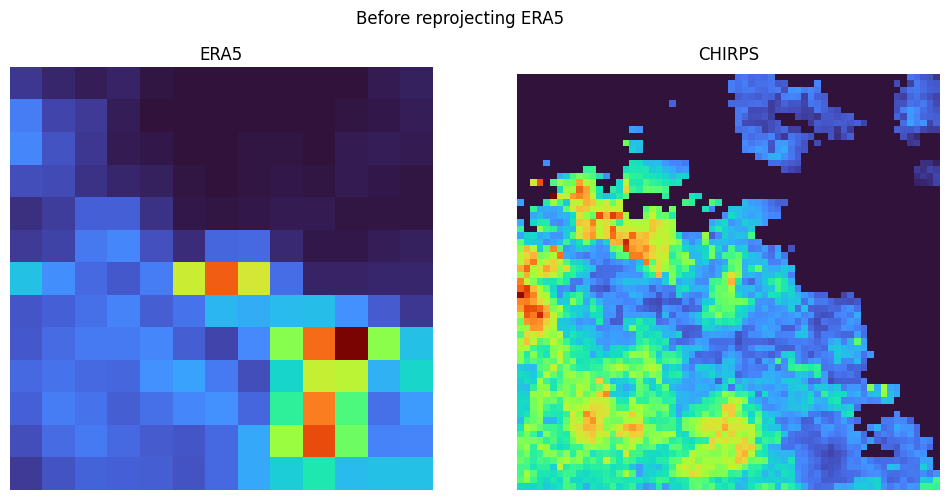

In [2]:
# File paths
source_file = "../../ERA5_daily_Uttarakhand/ERA5_daily_1981-08-19.tif"
reference_file = "../../CHIRPS_daily_Uttarakhand/CHIRPS_daily_2025-08-05.tif"
output_file = 'output.tif'

era5_tif = rs.open(source_file)
chirps_tif = rs.open(reference_file)

fig, (era5_ax, chirps_ax) = plt.subplots(1, 2, figsize=(12,7))
era5_ax.set_title("ERA5")
era5_ax.set_axis_off()
chirps_ax.set_title("CHIRPS")
chirps_ax.set_axis_off()
rplt.show(era5_tif.read(5), cmap="turbo", ax=era5_ax)
rplt.show(chirps_tif.read(1), cmap="turbo", ax=chirps_ax)
plt.suptitle("Before reprojecting ERA5", y=0.88)

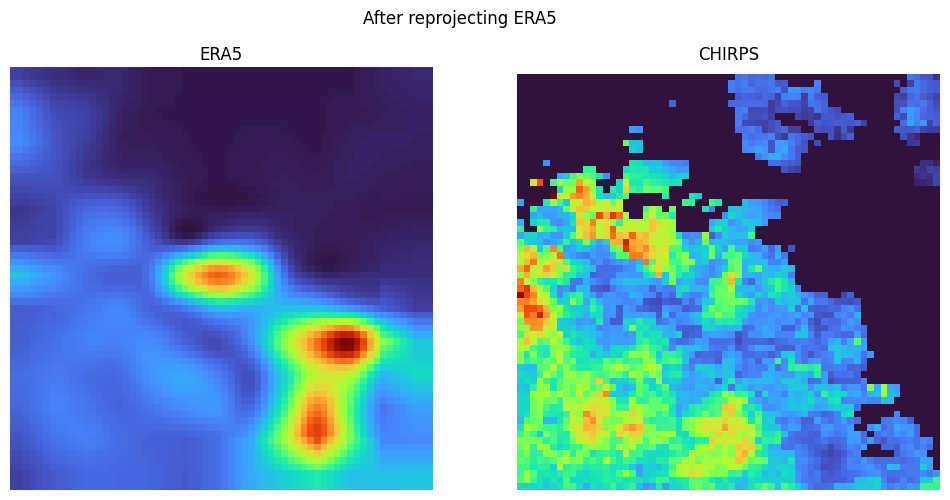

In [3]:
# 1. Open the source and reference files
with rs.open(source_file) as src:
    with rs.open(reference_file) as ref:
        
        # 2. Create a destination array with the dimensions and data type of the reference
        # This is where the reprojected data will be stored
        destination_array = np.empty(ref.shape, dtype=ref.dtypes[0])

        # 3. Perform the reprojection
        # This function does all the hard work of warping the source data to the
        # destination grid.
        reproject(
            source=rs.band(src, 5),
            destination=destination_array,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref.transform, # Apply transform of the reference!
            dst_crs=ref.crs,             # Apply CRS of the reference!
            dst_nodata=ref.nodata,
            resampling=Resampling.cubic # Choose your resampling method
        )

        # 4. Get the metadata from the reference file to use for the output
        # Update the profile with the correct data type from the reprojected array
        out_meta = ref.profile.copy()
        out_meta.update({
            "dtype": destination_array.dtype,
            "nodata": ref.nodata # Or specify a new nodata value
        })

# 5. Save the reprojected array to a new file
# with rs.open(output_file, "w", **out_meta) as dest:
#     dest.write(destination_array, 1)

# print(f"File '{output_file}' created successfully.")
# print(f"It now has the same CRS, transform, and dimensions as '{reference_file}'.")
fig, (era5_ax, chirps_ax) = plt.subplots(1, 2, figsize=(12,7))
era5_ax.set_title("ERA5")
era5_ax.set_axis_off()
chirps_ax.set_title("CHIRPS")
chirps_ax.set_axis_off()
rplt.show(destination_array, ax=era5_ax, cmap="turbo")
rplt.show(chirps_tif.read(1), ax=chirps_ax, cmap="turbo")
plt.suptitle("After reprojecting ERA5", y=0.88);
# era5_ax.imshow(destination_array, label="ERA5 REprojected", cmap="turbo")
# chirps_ax.imshow(chirps_tif.read(1), label="CHIRPS", cmap="turbo")